# Lab 03 — MLP bằng PyTorch

Thành viên 3. Dùng dữ liệu và pipeline chung trong `src/preprocessing.py` của thành viên 1. Metric: RMSE trên `log1p(SalePrice)`; train/validation 80/20, seed 42. Cài thư viện theo `requirements.txt`, sau đó chạy toàn bộ notebook.

In [1]:
from pathlib import Path
from dataclasses import asdict
import sys

PROJECT_ROOT = next(
    path for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "data/train.csv").is_file() and (path / "src/preprocessing.py").is_file()
)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import torch
from sklearn.model_selection import train_test_split
from IPython.display import display, Image
from src import preprocessing as pp
from src.mlp_model import HouseMLP, DEFAULT_CONFIGS
from src.train_mlp import (
    set_seed, dense_float32, target_statistics, standardize_target,
    make_loader, run_experiments, rmse,
)
from src.predict_mlp import load_mlp, predict_prices

torch.set_num_threads(2)
set_seed(pp.RANDOM_STATE)
print("pandas:", pd.__version__, "| PyTorch:", torch.__version__)

pandas: 3.0.6 | PyTorch: 2.14.1+cpu


## 1. Dữ liệu và preprocessing của thành viên 1

Giữ dtype gốc của `MSSubClass`, giữ các dòng outlier theo quyết định của người 1. Fit preprocessing và thống kê target chỉ trên train; validation/test chỉ transform. Dùng `sparse_threshold=0` để nhận ma trận dense cho PyTorch.

In [2]:
train, test = pp.load_data(PROJECT_ROOT / "data")
X, y = pp.split_feature_target(pp.add_target_log(train))
train_idx, valid_idx = train_test_split(
    np.arange(len(X)), test_size=0.2, random_state=pp.RANDOM_STATE, shuffle=True
)
X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
y_train, y_valid = y.iloc[train_idx].to_numpy(), y.iloc[valid_idx].to_numpy()

numeric_cols, categorical_cols = pp.select_column_groups(X_train)
preprocessor = pp.build_preprocessor(
    numeric_cols, categorical_cols, scale_numeric=True, sparse_threshold=0
)
X_train_processed = dense_float32(preprocessor.fit_transform(X_train))
X_valid_processed = dense_float32(preprocessor.transform(X_valid))
statistics = target_statistics(y_train)
y_train_scaled = standardize_target(y_train, statistics)

assert not set(train_idx) & set(valid_idx)
assert not {pp.ID_COLUMN, pp.TARGET_COLUMN, pp.TARGET_LOG_COLUMN} & set(X.columns)
assert np.isfinite(X_train_processed).all() and np.isfinite(X_valid_processed).all()
print("Numeric:", len(numeric_cols), "| Categorical:", len(categorical_cols))
print("Train:", X_train_processed.shape, "| Validation:", X_valid_processed.shape)

Numeric: 36 | Categorical: 43
Train: (1168, 285) | Validation: (292, 285)


## 2. Tensor, Dataset/DataLoader và kiến trúc MLP

Target huấn luyện là log1p đã chuẩn hóa bằng mean/std train. Hoàn tác chuẩn hóa trước khi tính RMSE. Đầu ra Linear có một neuron.

In [3]:
loader = make_loader(X_train_processed, y_train_scaled, DEFAULT_CONFIGS[0], pp.RANDOM_STATE)
X_batch, y_batch = next(iter(loader))
print("Batch:", X_batch.shape, y_batch.shape, X_batch.dtype)

model = HouseMLP(input_dim=X_train_processed.shape[1])
print(model)
assert model(X_batch).shape == y_batch.shape

display(pd.DataFrame([asdict(config) for config in DEFAULT_CONFIGS]))

Batch: torch.Size([64, 285]) torch.Size([64, 1]) torch.float32
HouseMLP(
  (network): Sequential(
    (0): Linear(in_features=285, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=128, out_features=64, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.2, inplace=False)
    (9): Linear(in_features=64, out_features=1, bias=True)
  )
)


,name,hidden_dims,dropout,batch_norm,learning_rate,weight_decay,batch_size
0,MLP_1_baseline,"(128, 64)",0.0,False,0.0010,0.0001,64
1,MLP_2_deeper,"(256, 128, 64)",0.2,False,0.0010,0.0001,64
2,MLP_3_batchnorm,"(512, 256, 128, 64)",0.2,True,0.0003,0.0001,64
3,MLP_2_lr_1e-2,"(256, 128, 64)",0.2,False,0.0100,0.0001,64
4,MLP_2_lr_3e-4,"(256, 128, 64)",0.2,False,0.0003,0.0001,64
5,MLP_2_dropout_0,"(256, 128, 64)",0.0,False,0.0010,0.0001,64
6,MLP_2_dropout_01,"(256, 128, 64)",0.1,False,0.0010,0.0001,64
7,MLP_2_dropout_03,"(256, 128, 64)",0.3,False,0.0010,0.0001,64


## 3. Huấn luyện và so sánh 8 cấu hình

MSELoss, AdamW, batch size 64, tối đa 400 epoch. Early stopping patience 40; giảm LR với ReduceLROnPlateau; lưu checkpoint tốt nhất theo validation RMSE. Mã train/validation nằm trong `src/train_mlp.py`. Sau khi chọn cấu hình, refit trên toàn bộ train để dự đoán test.

In [4]:
results, history, summary = run_experiments(
    project_dir=PROJECT_ROOT,
    configurations=DEFAULT_CONFIGS,
    feature_set="original",
    seed=pp.RANDOM_STATE,
    max_epochs=400,
    patience=40,
    validation_size=0.2,
    device="cpu",
    threads=2,
)
display(results[[
    "model", "hidden_layers", "learning_rate", "dropout", "batch_norm",
    "train_rmse_at_best", "val_rmse", "best_epoch", "epochs_run",
]])
print("Baseline RMSE:", summary["dummy_val_rmse"])
print("Best model:", summary["best_model"])
print("Validation RMSE:", summary["best_validation_rmse"])

Train=1168, validation=292, features=285, device=cpu, mean baseline RMSE=0.43324


  MLP_1_baseline: epoch=1, train RMSE=0.19609, val RMSE=0.20139, best=0.20139


Finished MLP_1_baseline: best epoch=7, RMSE=0.13280


  MLP_2_deeper: epoch=1, train RMSE=0.22022, val RMSE=0.22353, best=0.22353


  MLP_2_deeper: epoch=50, train RMSE=0.03197, val RMSE=0.13872, best=0.13124


...

  Full-data refit: epoch 22/22, loss=0.06158


Saved 1459 predictions: E:\nhomdeeplearning\GROUP_DEEEP_LEARNING_HK1_2026\TUAN03\lab03_house_price\outputs\submissions\submission_mlp.csv


           model  val_rmse  best_epoch
   MLP_2_lr_3e-4  0.129399          22
MLP_2_dropout_01  0.129988           9
 MLP_2_dropout_0  0.130886           7
    MLP_2_deeper  0.131240          10
 MLP_3_batchnorm  0.131474          97
MLP_2_dropout_03  0.132119          10
  MLP_1_baseline  0.132800           7
   MLP_2_lr_1e-2  0.132817           9


,model,hidden_layers,learning_rate,dropout,batch_norm,train_rmse_at_best,val_rmse,best_epoch,epochs_run
0,MLP_2_lr_3e-4,256-128-64,0.0003,0.2,False,0.079953,0.129399,22,62
1,MLP_2_dropout_01,256-128-64,0.0010,0.1,False,0.080760,0.129988,9,49
2,MLP_2_dropout_0,256-128-64,0.0010,0.0,False,0.083826,0.130886,7,47
3,MLP_2_deeper,256-128-64,0.0010,0.2,False,0.083547,0.131240,10,50
4,MLP_3_batchnorm,512-256-128-64,0.0003,0.2,True,0.047782,0.131474,97,137
5,MLP_2_dropout_03,256-128-64,0.0010,0.3,False,0.091145,0.132119,10,50
6,MLP_1_baseline,128-64,0.0010,0.0,False,0.089548,0.132800,7,47
7,MLP_2_lr_1e-2,256-128-64,0.0100,0.2,False,0.087643,0.132817,9,49


Baseline RMSE: 0.43324391618066094
Best model: MLP_2_lr_3e-4
Validation RMSE: 0.12939907549697288


## 4. Loss curve và kết quả validation

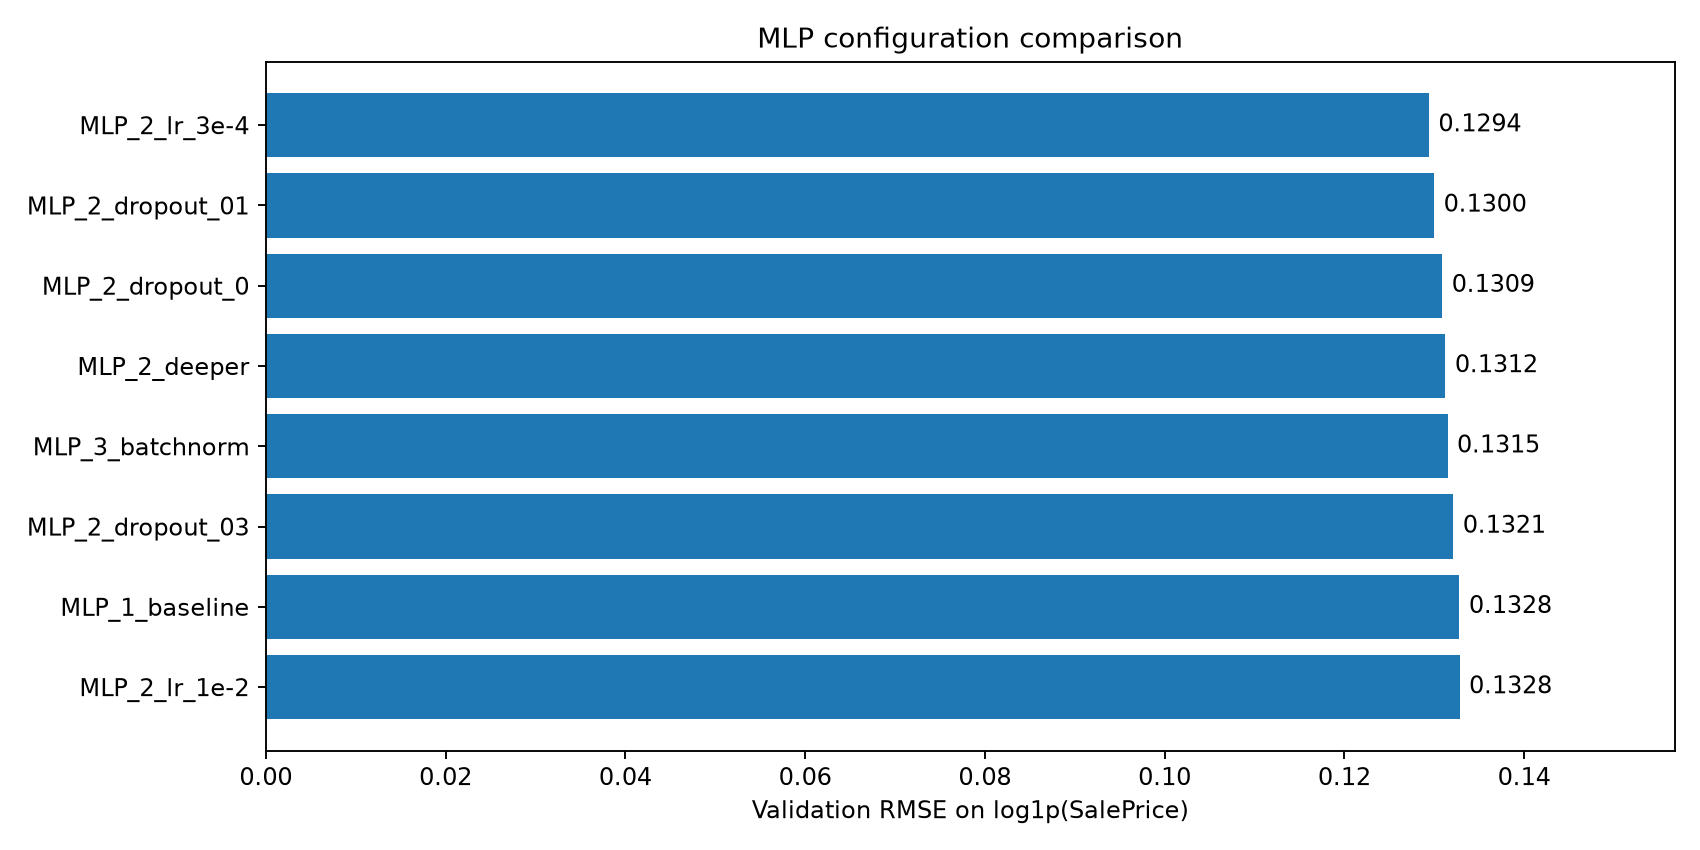

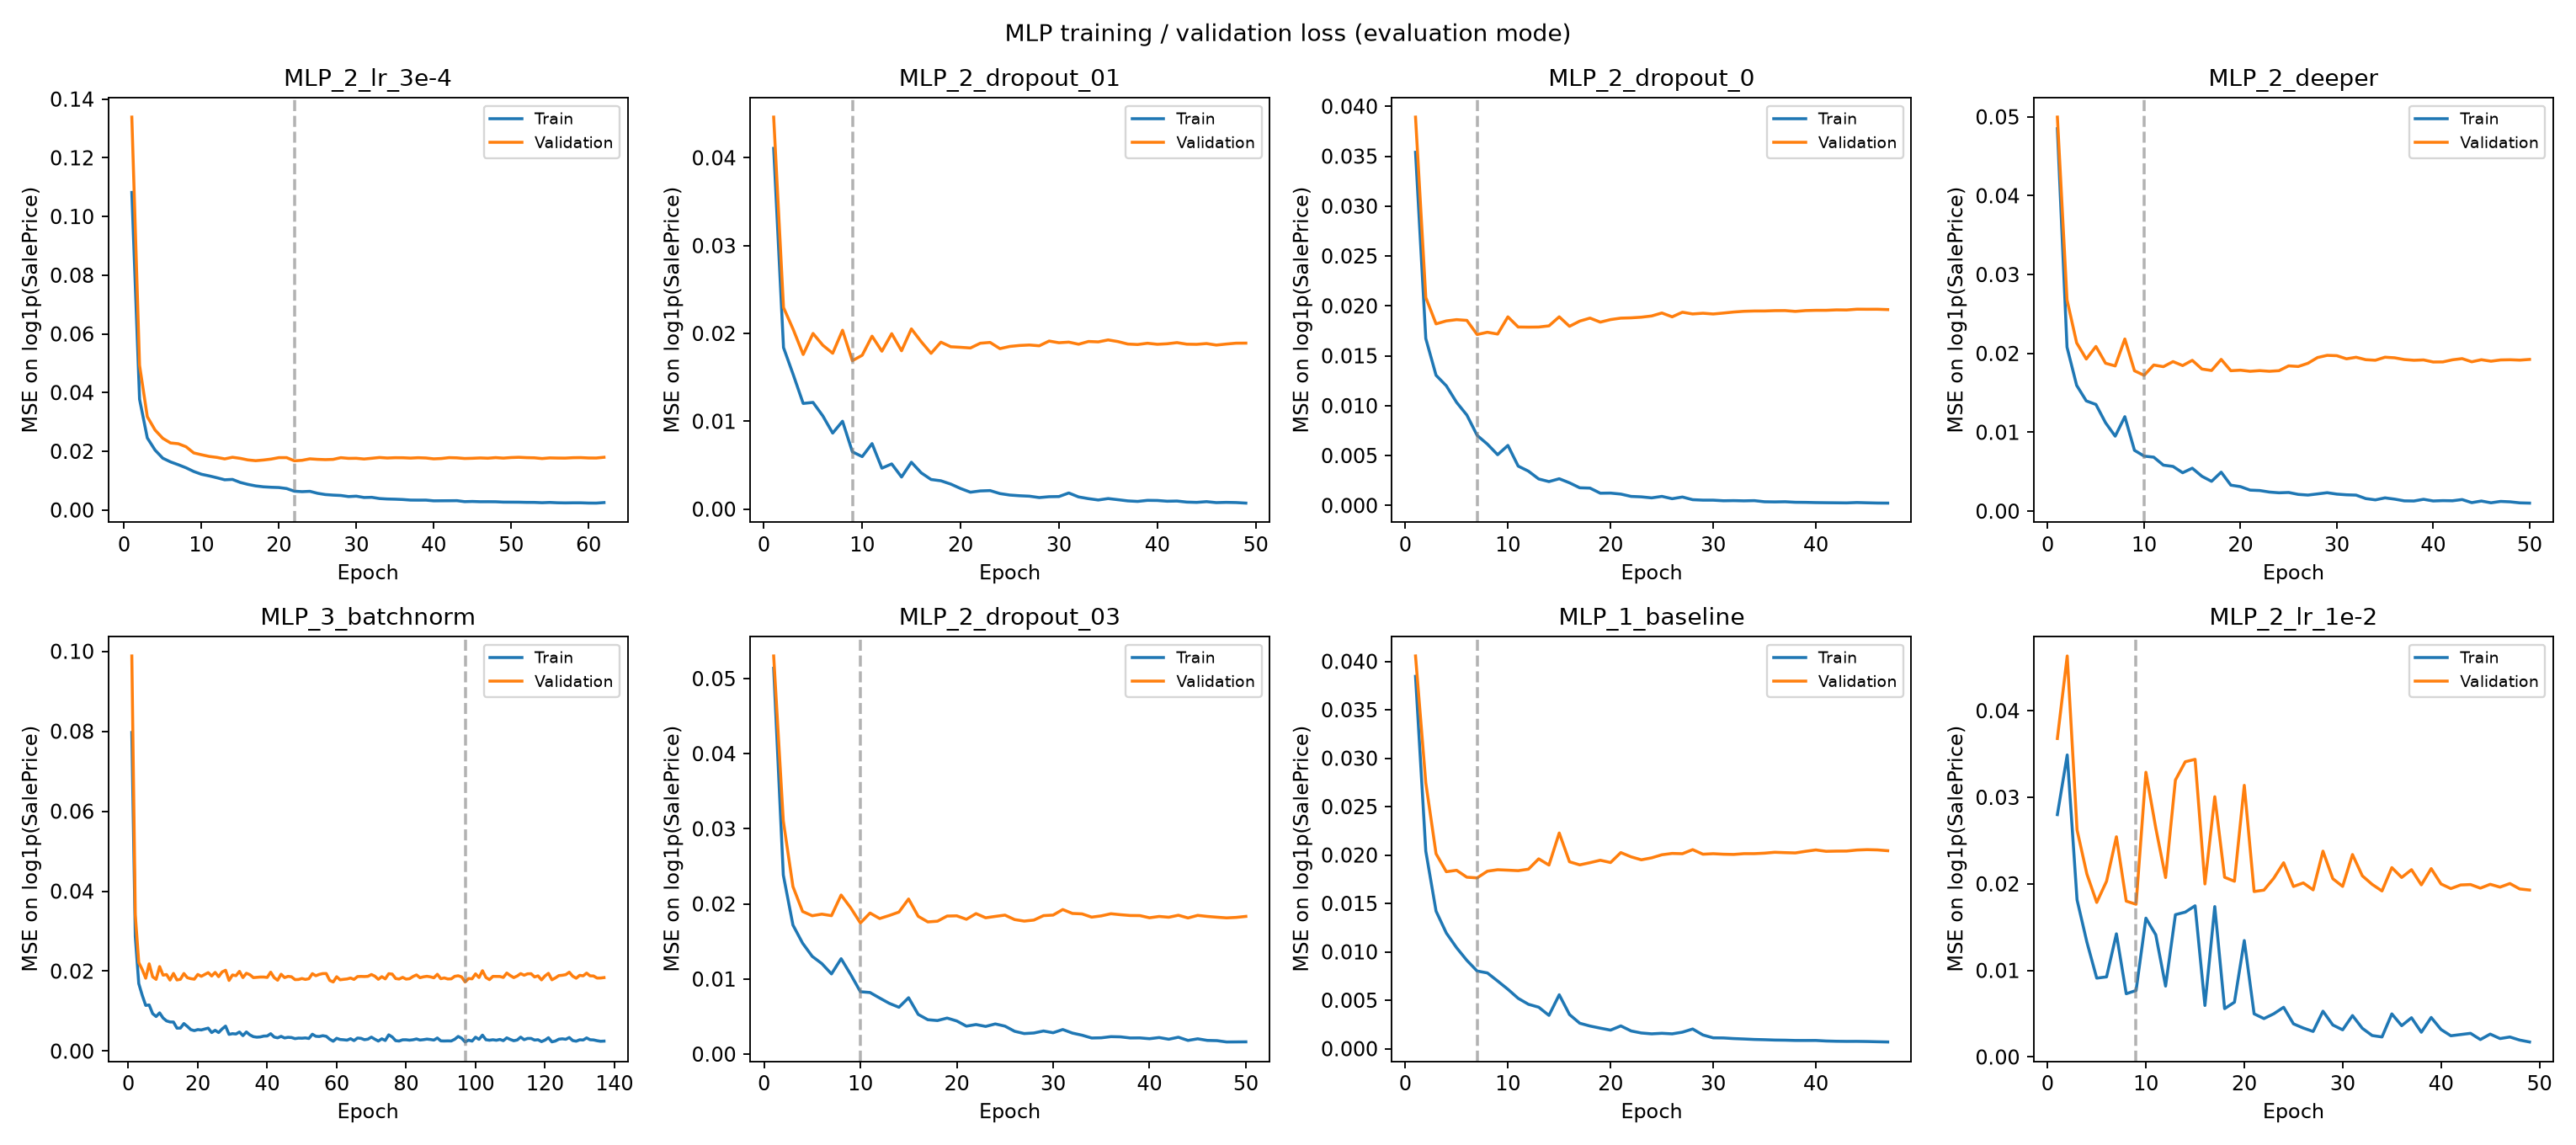

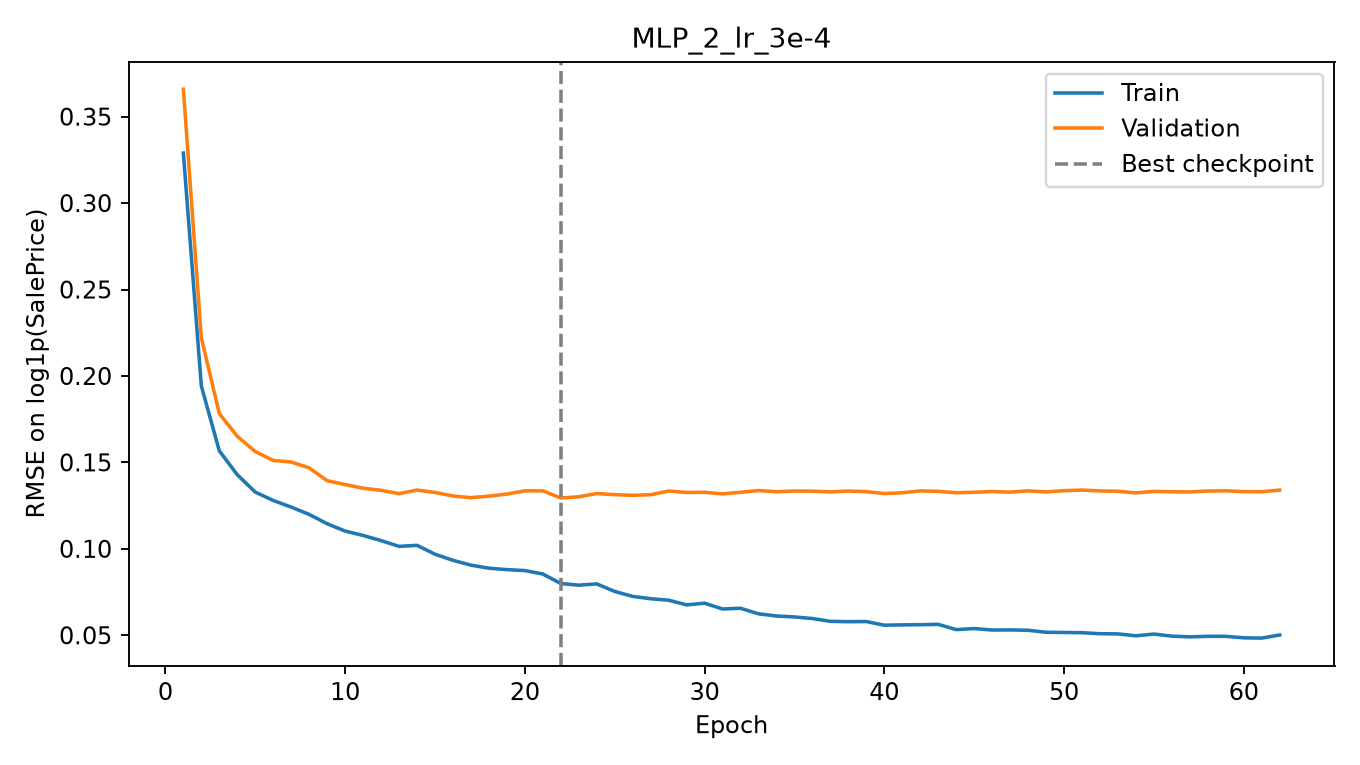

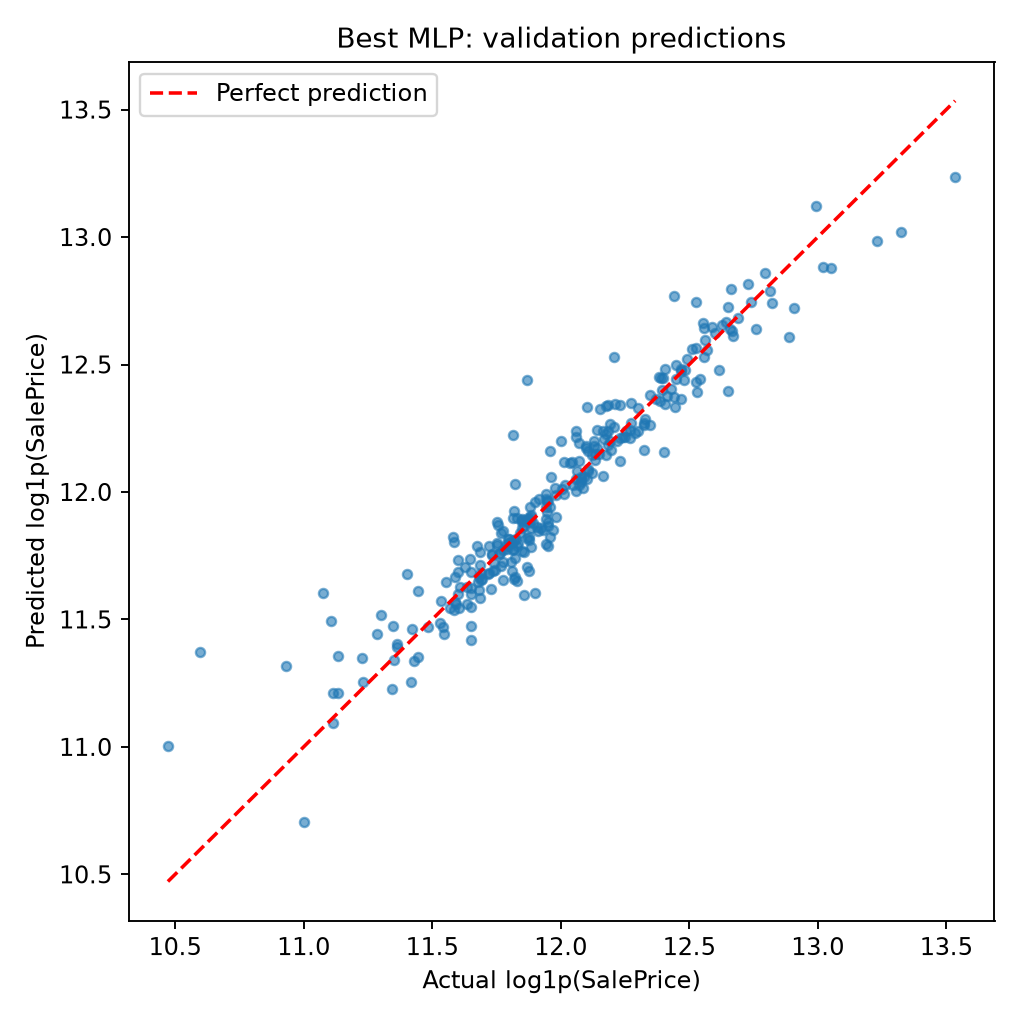

In [5]:
for filename in [
    "mlp_comparison.png", "mlp_loss_curves.png",
    "mlp_best_learning_curve.png", "mlp_validation_predictions.png",
]:
    display(Image(filename=str(PROJECT_ROOT / "outputs/figures" / filename)))

## 5. Kiểm tra nạp lại best checkpoint

In [6]:
best_model, best_preprocessor, best_checkpoint = load_mlp(
    PROJECT_ROOT, checkpoint="models/best_mlp.pt"
)
validation_prices = predict_prices(
    train.iloc[valid_idx], best_model, best_preprocessor, best_checkpoint
)
reloaded_rmse = rmse(y_valid, np.log1p(validation_prices))
assert np.isclose(reloaded_rmse, summary["best_validation_rmse"], atol=1e-7)
print("RMSE sau khi nạp checkpoint:", reloaded_rmse)
print("Best epoch:", best_checkpoint["best_epoch"])

RMSE sau khi nạp checkpoint: 0.12939907549697288
Best epoch: 22


## 6. Dự đoán test và file bàn giao

`models/best_mlp.pt` + `models/mlp_preprocessor.joblib`: checkpoint đánh giá validation.

`models/mlp_submission.pt` + `models/mlp_submission_preprocessor.joblib`: model refit toàn bộ train để dự đoán test. File kết quả: `outputs/submissions/submission_mlp.csv`. Bảng RMSE và lịch sử train nằm trong `outputs/results/`; hình trong `outputs/figures/`.

Validation là một holdout, được dùng để chọn cấu hình. Chưa có điểm Kaggle; checkpoint refit không có điểm validation độc lập riêng.

In [7]:
submission = pd.read_csv(PROJECT_ROOT / "outputs/submissions/submission_mlp.csv")
sample = pd.read_csv(PROJECT_ROOT / "data/sample_submission.csv")
submission_model, submission_preprocessor, submission_checkpoint = load_mlp(PROJECT_ROOT)
predicted_prices = predict_prices(
    test, submission_model, submission_preprocessor, submission_checkpoint
)
assert submission.shape == sample.shape
assert submission.columns.equals(sample.columns)
assert submission["Id"].equals(test["Id"])
assert submission["Id"].equals(sample["Id"])
assert np.allclose(predicted_prices, submission["SalePrice"], rtol=1e-12, atol=1e-8)
assert np.isfinite(predicted_prices).all() and (predicted_prices >= 0).all()
display(submission.head())
print("Số dự đoán:", len(submission))

,Id,SalePrice
0,1461,131108.020367
1,1462,159582.067067
2,1463,185904.964477
3,1464,202231.134605
4,1465,191891.979869


Số dự đoán: 1459
